<a href="https://colab.research.google.com/github/CristianoCoelhoSilva/Python/blob/master/PNAD_COVID.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Pesquisa Nacional por Amostra de Domicílios - PNAD COVID19

Objetiva estimar o número de pessoas com sintomas referidos associados à síndrome gripal e monitorar os impactos da pandemia da COVID-19 no mercado de trabalho brasileiro.

A coleta da Pesquisa Nacional por Amostra de Domicílios - PNAD COVID19 teve início em 4 de maio de 2020, com entrevistas realizadas por telefone em, aproximadamente, 48 mil domicílios por semana, totalizando cerca de 193 mil domicílios por mês, em todo o Território Nacional. A amostra é fixa, ou seja, os domicílios entrevistados no primeiro mês de coleta de dados permanecerão na amostra nos meses subsequentes, até o fim da pesquisa.

O questionário se divide em duas partes, sendo uma direcionada a questões de saúde, especificamente sobre sintomas associados à síndrome gripal e outra, a questões de trabalho. Nas questões de saúde, investiga-se a ocorrência de alguns dos principais sintomas da COVID19 no período de referência da pesquisa, considerando-se todos os moradores do domicílio. Para aqueles que apresentaram algum sintoma, perguntam-se quais as providências tomadas para alivio dos sintomas; se buscaram por atendimento médico devido a esses sintomas; e o tipo de estabelecimento de saúde procurado. Nas questões de trabalho, busca-se classificar a população em idade de trabalhar nas seguintes categorias: ocupados, desocupados e pessoas fora da força de trabalho. Investiga-se, ainda, os seguintes aspectos: ocupação e atividade; afastamento do trabalho e o motivo do afastamento; exercício de trabalho remoto; busca por trabalho; motivo por não ter procurado trabalho; horas semanais efetivamente e habitualmente trabalhadas; assim como o rendimento efetivo e habitual do trabalho. Por fim, visando compor o rendimento domiciliar, pergunta-se se algum morador recebeu outros rendimentos não oriundos do trabalho, tais como: aposentadoria, BPC-LOAS, Bolsa Família, algum auxílio emergencial relacionado à COVID, seguro desemprego, aluguel e outros. Cabe ressaltar que a PNAD COVID19 é uma pesquisa com instrumento dinâmico de coleta das informações; portanto, o questionário está sujeito a alterações ao longo do período de sua aplicação.

A pesquisa prevê divulgações semanais para alguns indicadores, em nível Brasil, e divulgações mensais para um conjunto mais amplo de indicadores, por Unidades da Federação.

Os resultados da PNAD COVID19 são pioneiros no sentido de constituírem a primeira divulgação de Estatísticas Experimentais elaboradas pelo IBGE, as quais estão alinhadas com a estratégia de modernização do Instituto e permitem a ampliação das ofertas de informação para atender às necessidades de seus usuários.

https://www.ibge.gov.br/estatisticas/downloads-estatisticas.html?caminho=Trabalho_e_Rendimento/Pesquisa_Nacional_por_Amostra_de_Domicilios_PNAD_COVID19/Microdados/Dados

# Características dos dados

Parte 1 - Identificação e Controle
Parte A - Características gerais dos moradores
Parte B - COVID19 - Todos os moradores
Parte C - Características de trabalho das pessoas de 14 anos ou mais de idade
Parte D - Rendimento de outras fontes dos moradores de 14 anos ou mais de idade
Parte E - Empréstimos
Parte Suplementar 01 - Características da habitação


# Prospecção de Internação e sedação, entubação ou colocado em respiração artificial com ventilador de COVID-19 em relação aos sintomas sentidos e diagnóstico médico de alguma comorbidade


A COVID-19 afeta diferentes pessoas de diferentes maneiras. A maioria das pessoas infectadas apresentará sintomas leves a moderados da doença e não precisarão ser hospitalizadas. De acordo com a base de dados coletada e tratada, a nossa intenção é predizer qual é a chance de uma pessoa que sentiu algum dos sintomas (febre, tosse, dor de garganta, difilcudade de respirar dor de cabeça, dor no peito, nausea, nariz entupido ou escorrendo, fadiga, dor nos olhos, perdade de paladar ou olfato, dor muscular ou diarreia) e que tem ou não algum diagnostico de algum comorbidade como diabetes, obesidade, hipertensão, tuberculose, entre outros, aumentam a possíbilidade de internação ou entubação.

In [3]:
import csv
import matplotlib as mpl
import pandas as pd
import mpl_toolkits.mplot3d
from scipy.interpolate import *
import matplotlib.pyplot as plt
from sklearn import linear_model
import tkinter as tk
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import seaborn
import numpy as np
from sklearn.compose import make_column_transformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_selector, make_column_transformer
from sklearn.model_selection import KFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [4]:
#Arquivo completo
#df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid.csv")
#Arquivo com apenas 2 mil Observações
df = pd.read_csv(r"https://raw.githubusercontent.com/CristianoCoelhoSilva/Python/master/Python/covid_limit.csv")

In [10]:
#df
#df.columns
df.head
#type(df)

<bound method NDFrame.head of       NUMERO  SEMANA  NUMERO_ENTREVISTA  ...  ESTABELECIMENTO  B005  B006
0          6       2                  3  ...                2     4     4
1          9       3                  3  ...                2     4     4
2          9       3                  3  ...                1     4     4
3          1       2                  3  ...                1     4     4
4          1       2                  3  ...                1     4     4
...      ...     ...                ...  ...              ...   ...   ...
1940       8       4                  3  ...                2     4     4
1941       9       1                  3  ...                2     4     4
1942      10       4                  3  ...                1     2     4
1943      10       4                  3  ...                1     2     4
1944      10       4                  3  ...                1     2     4

[1945 rows x 35 columns]>

# Tratamento dos dados

# Passo 1

Vamos remover as colunas que julgamos não acrescentarem nenhum valor ao nosso modelo.


    NUMERO            - Número de Ordem
    SEMANA            - Semana no mês
    NUMERO_ENTREVISTA - Número da Entrevista
    NUMERO_ORDEM      - Número de Ordem
    UF                - Unidade Federativa
    SITUACAO          - Situação do domicílio (Urbana; Rural)
    DOMICILIO         - 
    RESPONDEU         - Quem respondeu ao questionário
    ESCOLARIDADE      - Nível escolar
 
# Passo 2

Para predizer se uma pessoa tem a possibilidade de ser internada vamos revomer a váriavel B006 - Durante a internação, foi sedado, entubado e colocado em respiração artificial com ventilador?


In [13]:
#Removendo as colunas
df.drop(["NUMERO","SEMANA","NUMERO_ENTREVISTA","NUMERO_ORDEM","UF","SITUACAO","DOMICILIO","RESPONDEU","ESCOLARIDADE"], axis="columns", inplace=True)
df.drop(["B006"], axis="columns", inplace=True)

In [ ]:
#result.columns
#result['B005'].value_counts()
#result['B006'].value_counts()
#result.isna().sum()

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop(['B005'], axis = "columns")
y = df.B005

In [17]:

column_names_train = df.drop(['B005'], axis = "columns").columns
column_name_target = df[['B005']].columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 13)

In [18]:
# Cria nosso pipeline para pré-processamento com imputação, dummização e normalização
encoder_imputer_scaled_transformer = make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

encoder_imputer_scaled_transformer.fit(X_train)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

# Treina o algoritmo knn com k = 3
knn = KNeighborsClassifier(n_neighbors = 3)

knn.fit(X_train_processed, y_train)

# Avalia a performance do algoritmo utilizando a métrica de accuracy
y_pred = knn.predict(X_test_processed)

accuracy = accuracy_score(y_true = y_test, 
                          y_pred = y_pred)

accuracy

0.8561643835616438

## Aplicando o $k$-fold cross-validation para avaliação do modelo

**O primeiro ponto importante é que, como a rotina de $k$-fold cross-validation já cria folds disjuntos para treinamento e teste, não há mais a necessidade de se realizar um holdout. Ou seja, usamos toda a base de dados.**

Vamos aplicar os passos de pré-processamento em toda base, tal como fizemos para os conjuntos de treinamento e de teste acima.

In [ ]:
X_processed = encoder_imputer_scaled_transformer.fit_transform(X)

Vamos aproveitar todo o código, mas agora vamos rodá-lo com um $k$-fold cross-validation com $k=10$. 

A função `cross_val_score` do subpacote `sklearn.model_selection` realiza o $k$-fold cross-validation de forma automática. 
Basta passarmos os folds no parâmetro `cv` e a métrica de avaliação no parâmetro `scoring`. 
Lembrar que devemos treinar usando o conjunto de treinamento já pré-processado.

In [ ]:
from sklearn.model_selection import cross_val_score

folds = KFold(n_splits=10, shuffle=True).split(X_processed)

scores = cross_val_score(estimator = knn, 
                         X = X_processed, # usamos a base completa agora
                         y = y, 
                         cv = folds, 
                         scoring = 'accuracy')

print("Acurácia em cada fold: {}".format(scores))
print("Acurácia média nos folds: {}".format(np.mean(scores)))

Acurácia em cada fold: [0.84  0.815 0.885 0.845 0.86  0.87  0.89  0.86  0.91  0.8  ]
Acurácia média nos folds: 0.8575000000000002


In [ ]:
from sklearn.model_selection import StratifiedKFold

folds = StratifiedKFold(n_splits=10, shuffle=True).split(X_processed, y = y)

scores = cross_val_score(estimator = knn, 
                         X = X_processed, # usamos a base completa agora
                         y = y, 
                         cv = folds, 
                         scoring = 'accuracy')

print("Acurácia em cada fold: {}".format(scores))
print("Acurácia média nos folds: {}".format(np.mean(scores)))

Acurácia em cada fold: [0.89  0.855 0.895 0.865 0.855 0.825 0.86  0.845 0.84  0.875]
Acurácia média nos folds: 0.8605


In [ ]:
scores = cross_val_score(estimator = knn, 
                         X = X_processed, # usamos a base completa agora
                         y = y, 
                         cv=10, 
                         scoring='accuracy')

print("Acurácia em cada fold: {}".format(scores))
print("Acurácia média nos folds: {}".format(np.mean(scores)))

Acurácia em cada fold: [0.88  0.885 0.88  0.855 0.86  0.84  0.85  0.825 0.78  0.86 ]
Acurácia média nos folds: 0.8515


## Qual é o efeito da quantidade de folds nas estimativas?

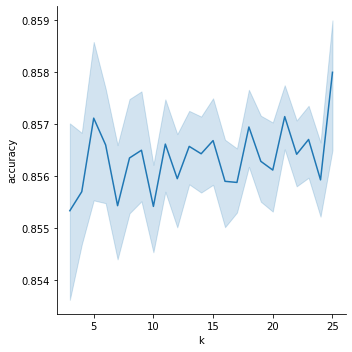

In [ ]:
df = pd.DataFrame(results_cross_validation,columns=['k','time_id', 'accuracy'])

seaborn.relplot(data = df,
                x = 'k',
                y = 'accuracy',
                kind = 'line')
plt.show()


In [ ]:
from sklearn.model_selection import LeaveOneOut

kf = LeaveOneOut().split(X_processed)

scores = cross_val_score(estimator = knn, 
                         X = X_processed, 
                         y = y, 
                         cv = kf, 
                         scoring = 'accuracy')

print("Acurácia em cada fold (usando leave-one-out): {}".format(scores))
print("Acurácia média nos folds (usando leave-one-out): {}".format(np.mean(scores)))

## Utilizando o $k$-fold cross-validation para seleção do modelo

In [ ]:
# Faz a divisão estratificada via holdout com 70% para conjunto de treinamento e 30% para conjunto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3)

X_train_processed = encoder_imputer_scaled_transformer.transform(X_train)
X_test_processed = encoder_imputer_scaled_transformer.transform(X_test)

In [ ]:
results = pd.DataFrame(columns=['n_neighbors', 'accuracy'])

for n_neighbors in range(1, 8):
  knn = KNeighborsClassifier(n_neighbors = n_neighbors)
  scores = cross_val_score(knn, X_train_processed, y_train, cv=8, scoring='accuracy')
  results = results.append({'n_neighbors' : n_neighbors,
                  'accuracy' : np.mean(scores)}, ignore_index = True)

results

,n_neighbors,accuracy
0,1.0,0.858571
1,2.0,0.832143
2,3.0,0.862857
3,4.0,0.865714
4,5.0,0.863571
5,6.0,0.872857
6,7.0,0.877143


O k que maximiza a acurácia no conjunto de treinamento é: 7


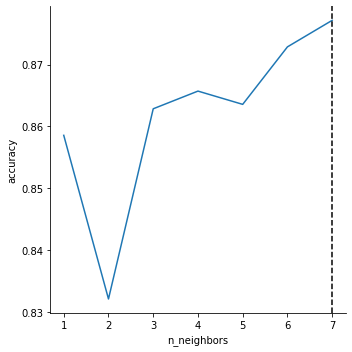

In [ ]:
import seaborn
import matplotlib.pyplot as plt

melhor_k = int(results[results.accuracy == results.accuracy.max()]['n_neighbors'].values[0])

seaborn.relplot(data = results,
                x = 'n_neighbors',
                y = 'accuracy',
                kind = 'line')
plt.axvline(x=melhor_k, color="black", linestyle= "--")

print("O k que maximiza a acurácia no conjunto de treinamento é: {}".format(melhor_k))

In [ ]:
knn_melhor_k = KNeighborsClassifier(n_neighbors=melhor_k)
knn_melhor_k.fit(X_train_processed, y_train)

y_pred = knn_melhor_k.predict(X_test_processed)

accuracy = accuracy_score(y_true = y_test, 
                          y_pred = y_pred)

accuracy

0.8383333333333334

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_valores = {"n_neighbors": range(1, 31)}

knn_automatico = GridSearchCV(estimator = KNeighborsClassifier(), 
                              param_grid = grid_valores, 
                              cv = 10,
                              scoring = 'accuracy',
                              refit = True)

knn_automatico.fit(X_train_processed, y_train)

print("Melhor parâmetro do modelo knn: ")
print(knn_automatico.best_params_)

print("Desempenho médio no fold de validação: ")
print(np.mean(knn_automatico.cv_results_['mean_test_score']))

y_pred = knn_automatico.predict(X_test_processed)

accuracy = accuracy_score(y_true = y_test, 
                          y_pred = y_pred)

print("Desempenho médio no fold de teste: ")
accuracy


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:667: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


Melhor parâmetro do modelo knn: 
{'n_neighbors': 18}
Desempenho médio no fold de validação: 
0.8829761904761906
Desempenho médio no fold de teste: 


0.855

# Integrando pré-processamento e classificador em um pipeline único

In [ ]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("preprocessamento", encoder_imputer_scaled_transformer),
    ("knn", KNeighborsClassifier())
])

grid_valores = {"knn__n_neighbors": range(1, 31)}

classificador = GridSearchCV(estimator = pipeline, 
                              param_grid = grid_valores,
                              cv = 10, 
                              scoring = "accuracy", 
                              refit = True)

classificador

GridSearchCV(cv=10, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessamento',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('knnimputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                    

In [ ]:
classificador.fit(X_train, y_train)

C:\ProgramData\Anaconda3\lib\site-packages\sklearn\model_selection\_split.py:667: UserWarning: The least populated class in y has only 8 members, which is less than n_splits=10.
  % (min_groups, self.n_splits)), UserWarning)


GridSearchCV(cv=10, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('preprocessamento',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='passthrough',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('knnimputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                    

In [ ]:
print("Melhor parâmetro do modelo knn: ")
print(classificador.best_params_)

print("Desempenho médio no fold de teste: ")
print(np.mean(classificador.cv_results_['mean_test_score']))

Melhor parâmetro do modelo knn: 
{'knn__n_neighbors': 18}
Desempenho médio no fold de teste: 
0.883357142857143


In [ ]:
y_pred = classificador.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.855

# Pushing to the limits

In [ ]:
make_column_transformer(
    (make_pipeline(
        (KNNImputer(n_neighbors = 3)),
        (StandardScaler())
    ) , make_column_selector(dtype_include = np.number)),
    (make_pipeline(
        SimpleImputer(strategy = 'most_frequent'),
        OneHotEncoder(handle_unknown = 'ignore'),
    ), make_column_selector(dtype_exclude = np.number)),
    remainder = 'passthrough'
)

ColumnTransformer(n_jobs=None, remainder='passthrough', sparse_threshold=0.3,
                  transformer_weights=None,
                  transformers=[('pipeline-1',
                                 Pipeline(memory=None,
                                          steps=[('knnimputer',
                                                  KNNImputer(add_indicator=False,
                                                             copy=True,
                                                             metric='nan_euclidean',
                                                             missing_values=nan,
                                                             n_neighbors=3,
                                                             weights='uniform')),
                                                 ('standardscaler',
                                                  StandardScaler(copy=True,
                                                                 with_mean=True,
         

In [ ]:
from sklearn.compose import ColumnTransformer

pipeline_estendido = Pipeline([
    ("pre_process", make_column_transformer(
                              (Pipeline([
                                  ('imputer', KNNImputer(n_neighbors = 3)),
                                  ('scaler', StandardScaler())
                              ]) , make_column_selector(dtype_include = np.number)),
                              (Pipeline([
                                  ("imputer", SimpleImputer(strategy = 'most_frequent', fill_value = "unknown")),
                                  ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
                              ]), make_column_selector(dtype_exclude = np.number))
                          )),
    ("knn", KNeighborsClassifier())                           
])

pipeline_estendido

Pipeline(memory=None,
         steps=[('pre_process',
                 ColumnTransformer(n_jobs=None, remainder='drop',
                                   sparse_threshold=0.3,
                                   transformer_weights=None,
                                   transformers=[('pipeline-1',
                                                  Pipeline(memory=None,
                                                           steps=[('imputer',
                                                                   KNNImputer(add_indicator=False,
                                                                              copy=True,
                                                                              metric='nan_euclidean',
                                                                              missing_values=nan,
                                                                              n_neighbors=3,
                                                                   

In [ ]:
import pprint as pp

pp.pprint(sorted(pipeline_estendido.get_params().keys()))

['knn',
 'knn__algorithm',
 'knn__leaf_size',
 'knn__metric',
 'knn__metric_params',
 'knn__n_jobs',
 'knn__n_neighbors',
 'knn__p',
 'knn__weights',
 'memory',
 'pre_process',
 'pre_process__n_jobs',
 'pre_process__pipeline-1',
 'pre_process__pipeline-1__imputer',
 'pre_process__pipeline-1__imputer__add_indicator',
 'pre_process__pipeline-1__imputer__copy',
 'pre_process__pipeline-1__imputer__metric',
 'pre_process__pipeline-1__imputer__missing_values',
 'pre_process__pipeline-1__imputer__n_neighbors',
 'pre_process__pipeline-1__imputer__weights',
 'pre_process__pipeline-1__memory',
 'pre_process__pipeline-1__scaler',
 'pre_process__pipeline-1__scaler__copy',
 'pre_process__pipeline-1__scaler__with_mean',
 'pre_process__pipeline-1__scaler__with_std',
 'pre_process__pipeline-1__steps',
 'pre_process__pipeline-1__verbose',
 'pre_process__pipeline-2',
 'pre_process__pipeline-2__encoder',
 'pre_process__pipeline-2__encoder__categories',
 'pre_process__pipeline-2__encoder__drop',
 'pre_pro

In [ ]:
param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
    "knn__n_neighbors": range(1, 10)
}

classificador_estendido = GridSearchCV(estimator = pipeline_estendido,
                                       param_grid = param_grid_estendido,
                                       scoring = "accuracy",
                                       cv = 5,
                                       refit = True)

In [ ]:
classificador_estendido.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('pre_process',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='drop',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('imputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                                    

In [ ]:
classificador_estendido.best_params_

{'knn__n_neighbors': 7,
 'pre_process__pipeline-1__imputer__n_neighbors': 1,
 'pre_process__pipeline-2__imputer__strategy': 'most_frequent'}

In [ ]:
y_pred = classificador_estendido.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.845

Podemos também deixar passos do pipeline como opcionais. Isso pode ser feito para todos os passos intermediários do pipeline, mas nunca com o último passo, que deve ser mandatório.

Para isso, basta utilizar o comando ``passthrough'' no passo que você deseja que seja opcional. Durante a otimização, o algoritmo irá determinar qual combinação maximiza/minimiza a métrica de interesse.

Na otimização abaixo, vamos tornar o scaling numérico nosso opcional e otimizar para isso também:


In [ ]:
param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 5),
    "pre_process__pipeline-1__scaler": ["passthrough", StandardScaler()], # o passo de normalização torna-se opcional
    "pre_process__pipeline-2__imputer__strategy": ['most_frequent', 'constant'],
    "knn__n_neighbors": range(1, 10)
}

classificador_estendido = GridSearchCV(estimator = pipeline_estendido,
                                       param_grid = param_grid_estendido,
                                       scoring = "accuracy",
                                       cv = 5,
                                       refit = True)

In [ ]:
pp.pprint(sorted(classificador_estendido.get_params().keys())) 

['cv',
 'error_score',
 'estimator',
 'estimator__knn',
 'estimator__knn__algorithm',
 'estimator__knn__leaf_size',
 'estimator__knn__metric',
 'estimator__knn__metric_params',
 'estimator__knn__n_jobs',
 'estimator__knn__n_neighbors',
 'estimator__knn__p',
 'estimator__knn__weights',
 'estimator__memory',
 'estimator__pre_process',
 'estimator__pre_process__n_jobs',
 'estimator__pre_process__pipeline-1',
 'estimator__pre_process__pipeline-1__imputer',
 'estimator__pre_process__pipeline-1__imputer__add_indicator',
 'estimator__pre_process__pipeline-1__imputer__copy',
 'estimator__pre_process__pipeline-1__imputer__metric',
 'estimator__pre_process__pipeline-1__imputer__missing_values',
 'estimator__pre_process__pipeline-1__imputer__n_neighbors',
 'estimator__pre_process__pipeline-1__imputer__weights',
 'estimator__pre_process__pipeline-1__memory',
 'estimator__pre_process__pipeline-1__scaler',
 'estimator__pre_process__pipeline-1__scaler__copy',
 'estimator__pre_process__pipeline-1__sca

In [ ]:
classificador_estendido.fit(X_train, y_train)

GridSearchCV(cv=5, error_score=nan,
             estimator=Pipeline(memory=None,
                                steps=[('pre_process',
                                        ColumnTransformer(n_jobs=None,
                                                          remainder='drop',
                                                          sparse_threshold=0.3,
                                                          transformer_weights=None,
                                                          transformers=[('pipeline-1',
                                                                         Pipeline(memory=None,
                                                                                  steps=[('imputer',
                                                                                          KNNImputer(add_indicator=False,
                                                                                                     copy=True,
                                    

In [ ]:
classificador_estendido.best_params_

{'knn__n_neighbors': 9,
 'pre_process__pipeline-1__imputer__n_neighbors': 1,
 'pre_process__pipeline-1__scaler': 'passthrough',
 'pre_process__pipeline-2__imputer__strategy': 'most_frequent'}

In [ ]:
y_pred = classificador_estendido.predict(X_test)

accuracy_score(y_pred = y_pred,
               y_true = y_test)

0.845

## [Opcional] Utilizando o nested $k$-fold cross-validation para seleção entre diferentes algoritmos

In [ ]:
from sklearn.model_selection import StratifiedKFold

pipeline_estendido = Pipeline([
    ("pre_process", make_column_transformer(
                              (Pipeline([
                                  ('imputer', KNNImputer(n_neighbors = 3)),
                                  ('scaler', StandardScaler())
                              ]) , make_column_selector(dtype_include = np.number)),
                              (Pipeline([
                                  ("imputer", SimpleImputer(strategy = 'most_frequent', fill_value = "unknown")),
                                  ("encoder", OneHotEncoder(handle_unknown = 'ignore'))
                              ]), make_column_selector(dtype_exclude = np.number))
                          )),
    ("knn", KNeighborsClassifier())                           
])

param_grid_estendido = {
    "pre_process__pipeline-1__imputer__n_neighbors": range(1, 3),
    "pre_process__pipeline-1__scaler": ["passthrough", StandardScaler()], # o passo de normalização torna-se opcional
    "knn__n_neighbors": range(5, 10)
}

# Quantidade de folds no outer loop
outer_folds_cv = StratifiedKFold(n_splits= 5, shuffle = True)

# Quantidade de folds no inner loop
inner_folds_cv = StratifiedKFold(n_splits = 5, shuffle = True)

classifier_nested_cv = GridSearchCV(estimator=pipeline_estendido, param_grid=param_grid_estendido, cv=inner_folds_cv)

# Rodo na base toda, sem precisar fazer uma pré-divisão com holdout
nested_score = cross_val_score(classifier_nested_cv, X=X, y=y, cv=outer_folds_cv)

In [ ]:
print("A acurácia de cada melhor conjunto de parâmetros em cada outer fold é {}".format(nested_score))

print("A acurácia média sem viés é: {}".format(np.mean(nested_score)))

A acurácia de cada melhor conjunto de parâmetros em cada outer fold é [0.87   0.8775 0.8725 0.8775 0.8725]
A acurácia média sem viés é: 0.874


# Sumarização de métodos usuais para divisão de dados

**Vantagens da validação cruzada:**

- Estimativa mais precisa do desempenho fora da amostra (conjunto de teste)
- Uso mais "eficiente" de dados: cada observação é usada exatamente uma vez para teste, evitando variabilidade decorrente da divisão aleatória de dados.


**Vantagens do holdout**

- Executa $k$ vezes mais rápido do que a validação cruzada $k$-fold
- Mais simples para examinar os resultados detalhados do processo de teste


**Recomendações de validação cruzada**

- $k$ pode ser qualquer número, mas $k \in \{5, 10\}$ geralmente é recomendado
- Para problemas de classificação, a **amostragem estratificada** é recomendada para criar os folds para garantir mesma proporção de classes em cada fold
- A função `cross_val_score` do `scikit-learn` faz isso por padrão


**O que não vimos ainda?**

- Bases de dados em que há uma dimensão temporal nos dados. Todas as divisões que fizemos assumem que cada item de dado é identicamente e independemente distribuiídos (iid). Existem métodos específicos para isso, tal como janela deslizante temporal.

In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_pred = y_pred,
                 y_true = y_test)

array([[  0,   0,   0,  11],
       [  0,   0,   0,  66],
       [  0,   0,   0,   1],
       [  0,   4,   0, 518]], dtype=int64)

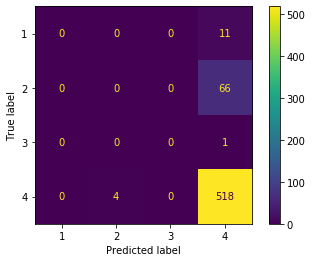

In [ ]:
from sklearn.metrics import plot_confusion_matrix

plot_confusion_matrix(classificador_estendido, X_test, y_test, values_format = '')

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_pred = y_pred,
                            y_true = y_test))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00        11
           2       0.00      0.00      0.00        66
           3       0.00      0.00      0.00         1
           4       0.87      0.99      0.93       522

    accuracy                           0.86       600
   macro avg       0.22      0.25      0.23       600
weighted avg       0.76      0.86      0.81       600



C:\ProgramData\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [ ]:
from sklearn.metrics import roc_curve, auc

probs = classificador_estendido.predict_proba(X_test)


fpr, tpr, threshold = roc_curve(y_test, probs[:, 1])
roc_auc = auc(fpr, tpr)
roc_auc

In [ ]:
from sklearn.metrics import plot_roc_curve

plot_roc_curve(classificador_estendido, X_test, y_test)
identity_line, = plt.plot([0,1],
                          [0,1])
identity_line.set_dashes([5, 5, 5, 5])

In [ ]:
result['B005'].value_counts()

4    1754
2     211
1      24
3      11
Name: B005, dtype: int64

In [ ]:
classificador_estendido_roc_auc = GridSearchCV(estimator = pipeline_estendido,
                                                param_grid = param_grid_estendido,
                                                scoring = "roc_auc",
                                                cv = 4,
                                                refit = True)

classificador_estendido_roc_auc.fit(X_train, y_train)

In [ ]:
plot_confusion_matrix(classificador_estendido_roc_auc, X_test, y_test, values_format = '')

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [ ]:
plot_roc_curve(classificador_estendido_roc_auc, X_test, y_test)
identity_line, = plt.plot([0,1],
                          [0,1])
identity_line.set_dashes([5, 5, 5, 5])

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'